# Projet - Tâche 1 : Collecte de données

## Objectif

Dans cette partie, nous utilisons un jeu de données d'images de fleurs et nous appliquons un clustering de couleurs avec `KMeans`.

Le but est de :

1. charger un échantillon d'images ;
2. extraire les couleurs dominantes de chaque image ;
3. afficher les résultats de façon claire.


## Choix du dataset

Nous utilisons le dataset **Oxford Flowers 102** disponible sur Hugging Face.

Ce dataset est adapté à notre objectif car il contient beaucoup d'images de fleurs avec des couleurs variées.

Lien : [pufanyi/flowers102](https://huggingface.co/datasets/pufanyi/flowers102)


## Rappel des consignes du projet

D'après [Projet.md](fr/Projet/Projet.md), le projet complet demande notamment :

- de collecter au moins **100 images sous licence libre** ;
- de stocker les **métadonnées** dans un fichier JSON ;
- d'extraire les **couleurs prédominantes** avec `KMeans` ;
- d'enrichir ensuite les données pour construire un système de recommandation.

Dans ce notebook, nous traitons surtout la partie liée à l'extraction des couleurs, ce qui correspond à la transition entre la **collecte de données** et l'**étiquetage / annotation**.


## Chargement des données

Nous chargeons seulement 200 images pour garder un notebook simple et rapide à exécuter.


In [2]:
!pip install datasets

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 9.3 MB/s  0:00:00
   ---------------------------------------- 0.0/625.2 kB ? eta -:--:--
   ---------------------------------------- 625.2/625.2 kB 15.9 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 25.2 MB/s  0:00:00
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ------------ --------------------------- 8.7/27.5 MB 43.9 MB/s eta 0:00:01
   ----------------------- ---------------- 16.3/27.5 MB 39.8 MB/s eta 0:00:01
   ----------------------------------- ---- 24.4/27.5 MB 39.2 MB/s eta 0:00:01
   ---------------------------------------- 27.5/27.5 MB 36.0 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using

In [3]:
from datasets import load_dataset

ds = load_dataset("pufanyi/flowers102", split="train", streaming=True)

samples = []
for i, sample in enumerate(ds):
    if i == 200:
        break
    samples.append(sample)

len(samples)


README.md:   0%|          | 0.00/518 [00:00<?, ?B/s]

c:\venvs\dml_jupyter\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bquen\.cache\huggingface\hub\datasets--pufanyi--flowers102. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


200

## Préparation des images

Nous convertissons les images en RGB puis nous les stockons dans un `DataFrame` pandas.

Cela permet ensuite d'ajouter facilement de nouvelles colonnes pour les résultats du clustering.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.DataFrame({
    "label": [sample["label"] for sample in samples],
    "image": [sample["image"].convert("RGB") for sample in samples],
})

df.head()


,label,image
0,45,<PIL.Image.Image image mode=RGB size=752x500 a...
1,73,<PIL.Image.Image image mode=RGB size=667x500 a...
2,51,<PIL.Image.Image image mode=RGB size=500x667 a...
3,88,<PIL.Image.Image image mode=RGB size=667x500 a...
4,80,<PIL.Image.Image image mode=RGB size=667x500 a...


## Clustering des couleurs

Nous allons maintenant définir deux fonctions simples :

- une fonction qui redimensionne l'image ;
- une fonction qui applique `KMeans` sur les pixels RGB.

Chaque pixel est considéré comme un point dans un espace à 3 dimensions : rouge, vert et bleu.


In [5]:
def resize_image(image, max_size=128):
    image = image.copy()
    image.thumbnail((max_size, max_size))
    return image

def cluster_colors(image, n_colors=5):
    resized_image = resize_image(image)
    
    # Convertir l'image en un tableau de pixels normalisé
    pixels = np.array(resized_image, dtype=np.float32) / 255.0
    
    # Reshaper le tableau de pixels pour qu'il soit en 2D (nombre de pixels, 3)
    pixels_2d = pixels.reshape(-1, 3)

    # Appliquer le clustering KMeans aux pixels de l'image
    model = KMeans(n_clusters=n_colors, random_state=42, n_init="auto")
    labels = model.fit_predict(pixels_2d)

    # Obtenir les couleurs dominantes et reconstruire l'image segmentée
    centers = model.cluster_centers_
    segmented_pixels = centers[labels].reshape(pixels.shape)
    segmented_image = (segmented_pixels * 255).astype(np.uint8)

    # Calculer la fréquence de chaque couleur dominante
    counts = np.bincount(labels)
    
    # Trier les couleurs et leurs fréquences par ordre décroissant de fréquence
    order = np.argsort(counts)[::-1]

    # Obtenir la palette de couleurs triée et les fréquences correspondantes
    palette = centers[order]
    frequencies = counts[order]

    return resized_image, segmented_image, palette, frequencies


## Application sur toutes les images

Nous appliquons la même méthode à chaque image de l'échantillon.

On ajoute ensuite quatre colonnes au `DataFrame` :

- l'image redimensionnée ;
- l'image segmentée ;
- la palette de couleurs dominantes ;
- la fréquence de chaque couleur.


In [6]:
results = [cluster_colors(image, n_colors=5) for image in df["image"]]

df["resized_image"] = [result[0] for result in results]
df["clustered_image"] = [result[1] for result in results]
df["palette"] = [result[2] for result in results]
df["frequencies"] = [result[3] for result in results]

df[["label"]].head()


,label
0,45
1,73
2,51
3,88
4,80


## Visualisation des résultats

Pour quelques images, nous affichons :

1. l'image originale redimensionnée ;
2. l'image reconstruite après clustering ;
3. la palette des couleurs dominantes.


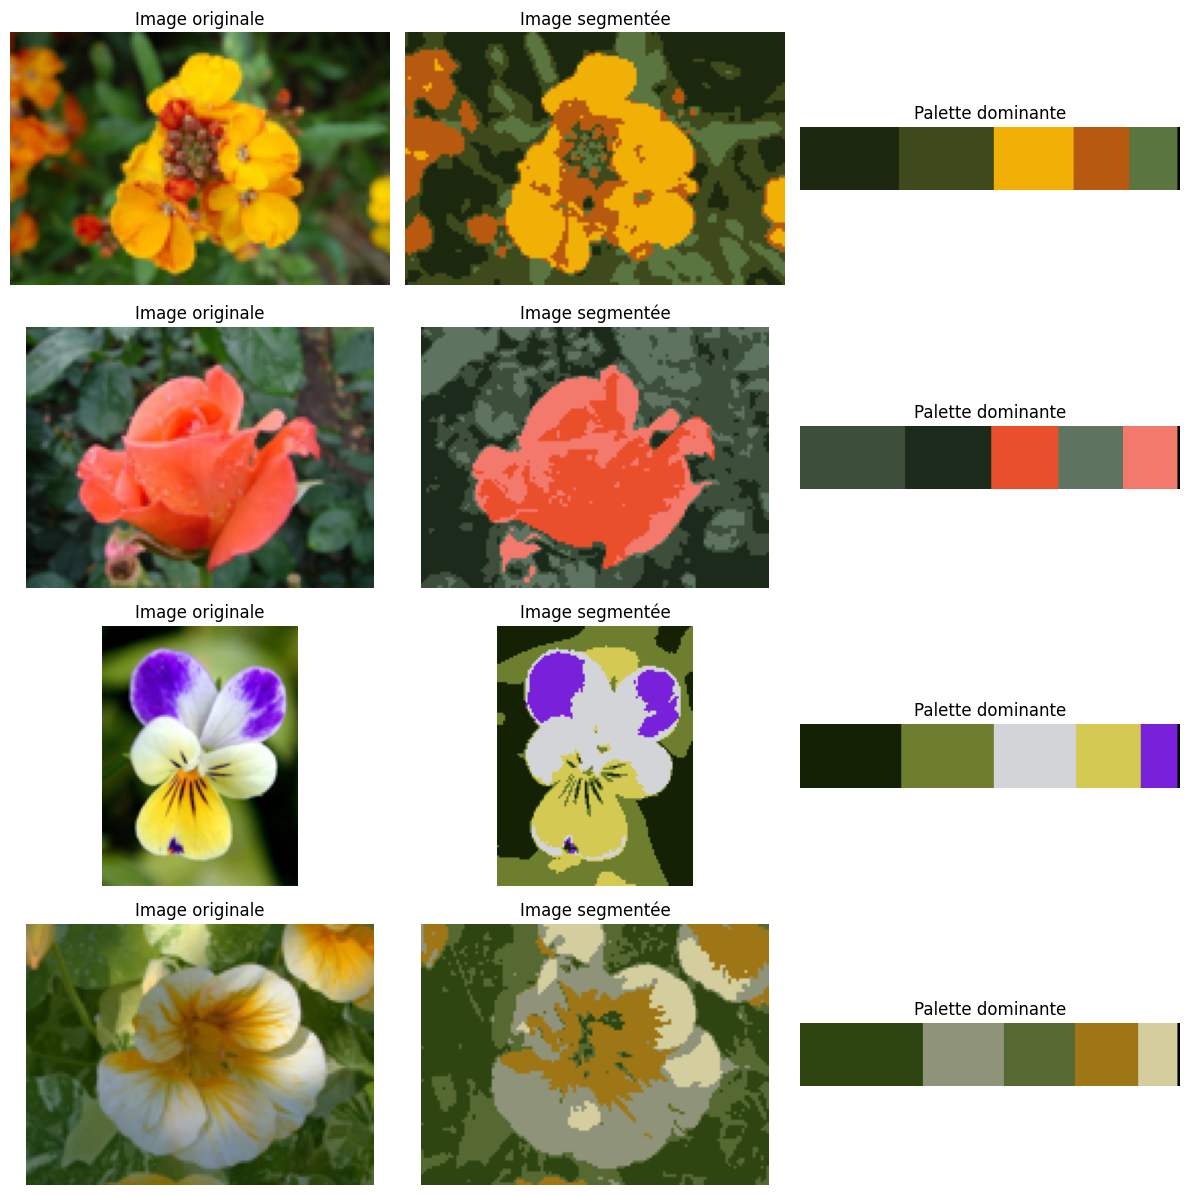

In [7]:
def palette_bar(colors, frequencies, width=300, height=50):
    frequencies = frequencies / frequencies.sum()
    bar = np.zeros((height, width, 3), dtype=np.uint8)

    start = 0
    for color, freq in zip(colors, frequencies):
        end = start + int(freq * width)
        bar[:, start:end] = (color * 255).astype(np.uint8)
        start = end

    return bar

sample_ids = [0, 1, 2, 3]
fig, axes = plt.subplots(len(sample_ids), 3, figsize=(12, 3 * len(sample_ids)))

for row, i in enumerate(sample_ids):
    axes[row, 0].imshow(df.loc[i, "resized_image"])
    axes[row, 0].set_title("Image originale")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(df.loc[i, "clustered_image"])
    axes[row, 1].set_title("Image segmentée")
    axes[row, 1].axis("off")

    bar = palette_bar(df.loc[i, "palette"], df.loc[i, "frequencies"])
    axes[row, 2].imshow(bar)
    axes[row, 2].set_title("Palette dominante")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()
